   FlightID    Airline  FlightNumber Origin Destination ScheduledDeparture  \
0         1     United          4558    ORD         MIA   01-09-2024 08:11   
1         2      Delta          8021    LAX         MIA   01-09-2024 10:25   
2         3  Southwest          7520    DFW         SFO   01-09-2024 16:53   
3         4      Delta          2046    ORD         BOS   01-09-2024 14:44   
4         5      Delta          6049    LAX         SEA   01-09-2024 01:51   

    ActualDeparture  ScheduledArrival     ActualArrival  DelayMinutes  \
0  01-09-2024 08:30  01-09-2024 12:11  01-09-2024 12:19             8   
1  01-09-2024 10:41  01-09-2024 13:25  01-09-2024 13:27             2   
2  01-09-2024 17:05  01-09-2024 17:53  01-09-2024 18:07            14   
3  01-09-2024 15:04  01-09-2024 18:44  01-09-2024 18:34           -10   
4  01-09-2024 02:08  01-09-2024 05:51  01-09-2024 06:15            24   

           DelayReason  Cancelled  Diverted AircraftType TailNumber  Distance  
0           

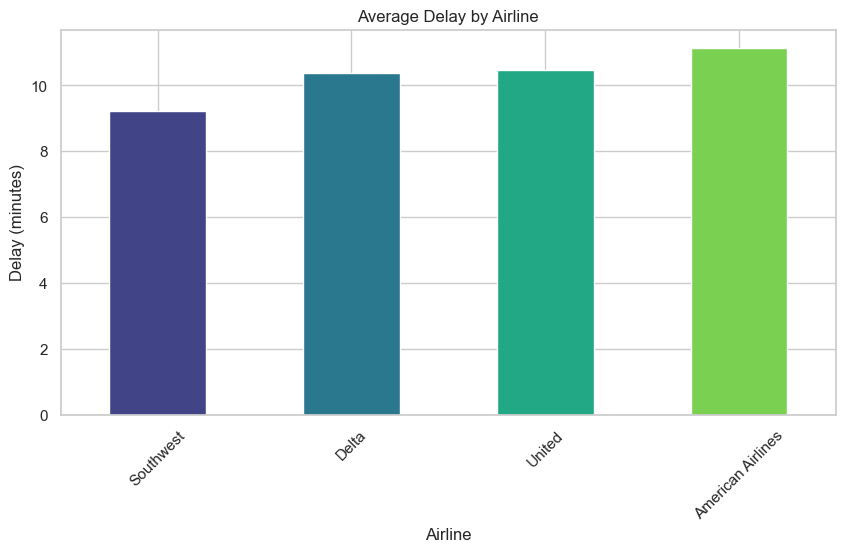

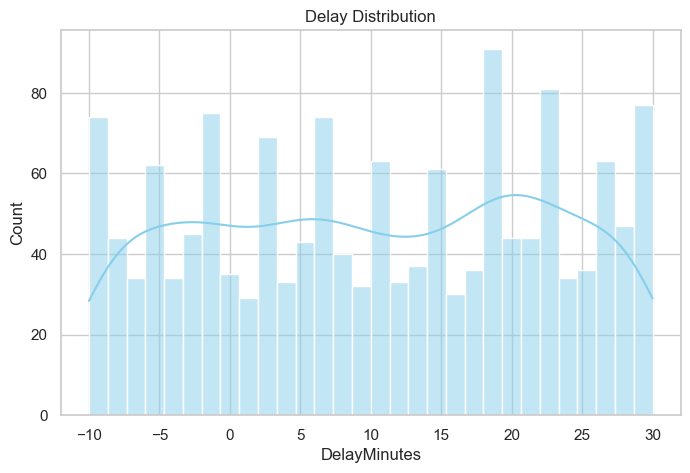

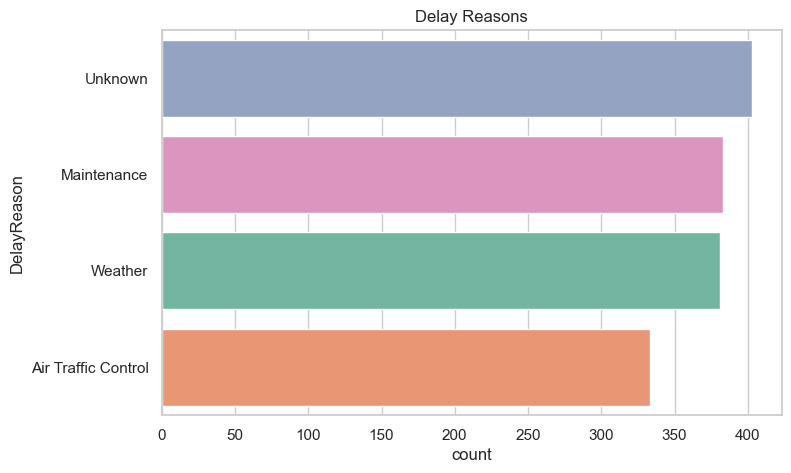

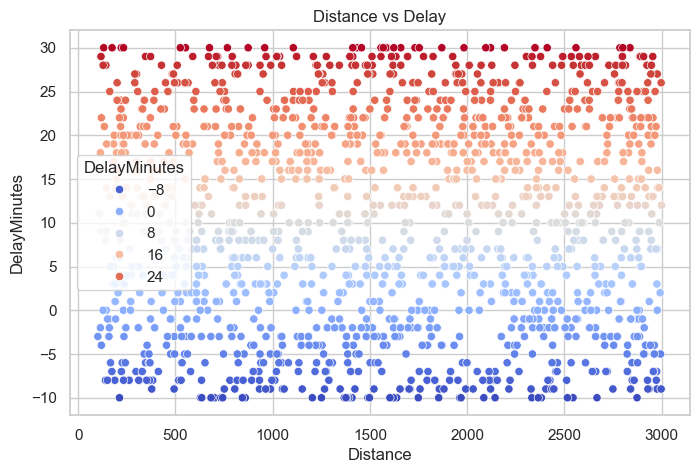

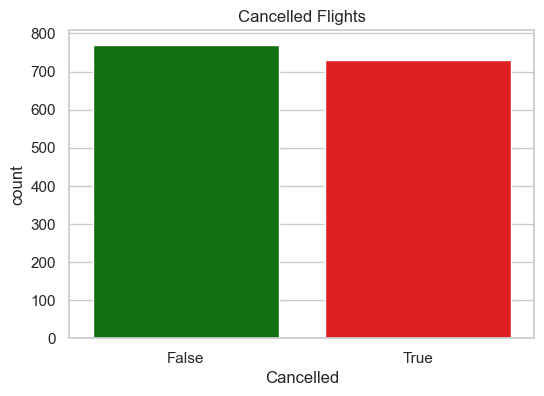

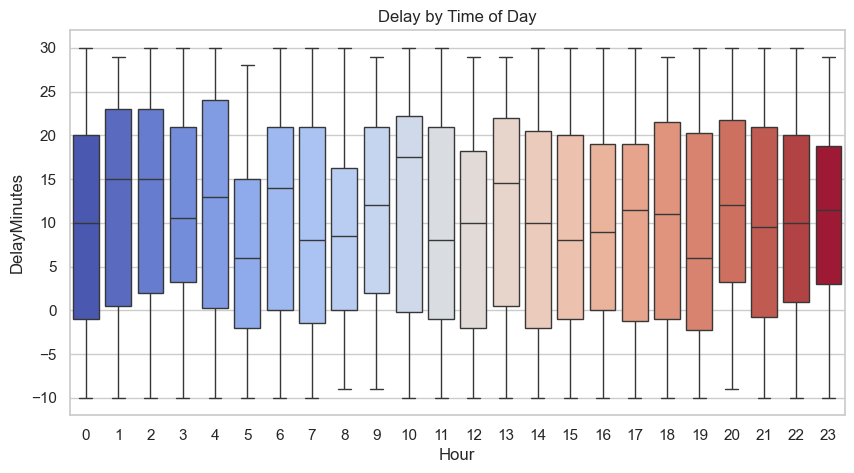


Task 1 Completed Successfully!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Flight Delay.csv")

print(df.head())
print(df.info())
print(df.describe())

print("\nMissing Values:\n", df.isnull().sum())

df['DelayReason'] = df['DelayReason'].fillna("Unknown")

df.drop_duplicates(inplace=True)

df['ScheduledDeparture'] = pd.to_datetime(df['ScheduledDeparture'])
df['ActualDeparture'] = pd.to_datetime(df['ActualDeparture'])
df['ScheduledArrival'] = pd.to_datetime(df['ScheduledArrival'])
df['ActualArrival'] = pd.to_datetime(df['ActualArrival'])

df['Hour'] = df['ScheduledDeparture'].dt.hour

sns.set(style="whitegrid")

plt.figure(figsize=(10,5))
df.groupby('Airline')['DelayMinutes'].mean().sort_values().plot(
    kind='bar',
    color=sns.color_palette("viridis", len(df['Airline'].unique()))
)
plt.title("Average Delay by Airline")
plt.ylabel("Delay (minutes)")
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(df['DelayMinutes'], bins=30, kde=True, color='skyblue')
plt.title("Delay Distribution")
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(y='DelayReason',data=df,order=df['DelayReason'].value_counts().index,hue='DelayReason',palette="Set2",legend=False)
plt.title("Delay Reasons")
plt.show()

# 4. Distance vs Delay
plt.figure(figsize=(8,5))
sns.scatterplot(x='Distance',y='DelayMinutes',data=df,hue='DelayMinutes',palette='coolwarm')
plt.title("Distance vs Delay")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='Cancelled',data=df,hue='Cancelled',palette=['green', 'red'],legend=False)
plt.title("Cancelled Flights")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(x='Hour',y='DelayMinutes',data=df,hue='Hour',palette="coolwarm",legend=False)
plt.title("Delay by Time of Day")
plt.show()

df.to_csv("cleaned_flight_data.csv", index=False)

print("\nTask 1 Completed Successfully!")